<a href="https://colab.research.google.com/github/kalaicoder14/TASK_05_Ecommerce_Return_Rate_Investigation/blob/main/task_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd

In [6]:
# load dataset
data=pd.read_csv("/content/ecommerce.csv")

In [7]:
#head
data.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,08-09-2020 9.38,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,05-03-2022 12.56,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,23-05-2022 18.18,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,12-11-2020 13.13,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,27-11-2020 17.55,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [8]:
# dimensions
data.shape

(499, 13)

In [9]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            499 non-null    int64  
 1   Purchase Date          499 non-null    object 
 2   Product Category       499 non-null    object 
 3   Product Price          499 non-null    int64  
 4   Quantity               499 non-null    int64  
 5   Total Purchase Amount  499 non-null    int64  
 6   Payment Method         499 non-null    object 
 7   Customer Age           499 non-null    int64  
 8   Returns                408 non-null    float64
 9   Customer Name          499 non-null    object 
 10  Age                    499 non-null    int64  
 11  Gender                 499 non-null    object 
 12  Churn                  499 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 50.8+ KB


In [10]:
# missing values
data.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,91
Customer Name,0


In [11]:
print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Records:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

# Handle missing values in Returns
data['Returns'] = data['Returns'].fillna(0)




Missing Values:
Customer ID               0
Purchase Date             0
Product Category          0
Product Price             0
Quantity                  0
Total Purchase Amount     0
Payment Method            0
Customer Age              0
Returns                  91
Customer Name             0
Age                       0
Gender                    0
Churn                     0
dtype: int64

Duplicate Records: 0


In [44]:
# Handle missing values in Returns
data['Returns'] = data['Returns'].fillna(0)

In [14]:
total_orders = len(data)
returned_orders = (data['Returns'] == 1).sum()
return_percentage = (returned_orders / total_orders) * 100

print("\nTotal Orders:", total_orders)
print("Returned Orders:", returned_orders)
print("Return Percentage:", round(return_percentage, 2), "%")


Total Orders: 499
Returned Orders: 210
Return Percentage: 42.08 %


In [15]:
# mean,median,std varaition,min,max,Quartiles
data.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,24072.088176,251.679359,2.985972,2647.496994,42.599198,0.420842,42.599198,0.234469
std,14885.318923,146.426254,1.370151,1409.334433,15.312268,0.494190,15.312268,0.424092
min,556.000000,11.000000,1.000000,241.000000,19.000000,0.000000,19.000000,0.000000
25%,10687.000000,118.500000,2.000000,1560.000000,30.000000,0.000000,30.000000,0.000000
50%,23703.000000,255.000000,3.000000,2660.000000,40.000000,0.000000,40.000000,0.000000
75%,36664.000000,381.000000,4.000000,3760.500000,55.000000,1.000000,55.000000,0.000000
max,49593.000000,498.000000,5.000000,5247.000000,70.000000,1.000000,70.000000,1.000000


In [18]:
print("\nProduct Price Statistics")
print(data['Product Price'].describe())

print("\nCustomer Age Statistics")
print(data['Customer Age'].describe())

print("\nPurchase Amount Statistics")
print(data['Total Purchase Amount'].describe())

print("\nMean Product Price:", data['Product Price'].mean())
print("Median Product Price:", data['Product Price'].median())
print("Std Product Price:", data['Product Price'].std())



Product Price Statistics
count    499.000000
mean     251.679359
std      146.426254
min       11.000000
25%      118.500000
50%      255.000000
75%      381.000000
max      498.000000
Name: Product Price, dtype: float64

Customer Age Statistics
count    499.000000
mean      42.599198
std       15.312268
min       19.000000
25%       30.000000
50%       40.000000
75%       55.000000
max       70.000000
Name: Customer Age, dtype: float64

Purchase Amount Statistics
count     499.000000
mean     2647.496994
std      1409.334433
min       241.000000
25%      1560.000000
50%      2660.000000
75%      3760.500000
max      5247.000000
Name: Total Purchase Amount, dtype: float64

Mean Product Price: 251.67935871743487
Median Product Price: 255.0
Std Product Price: 146.42625443115222


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

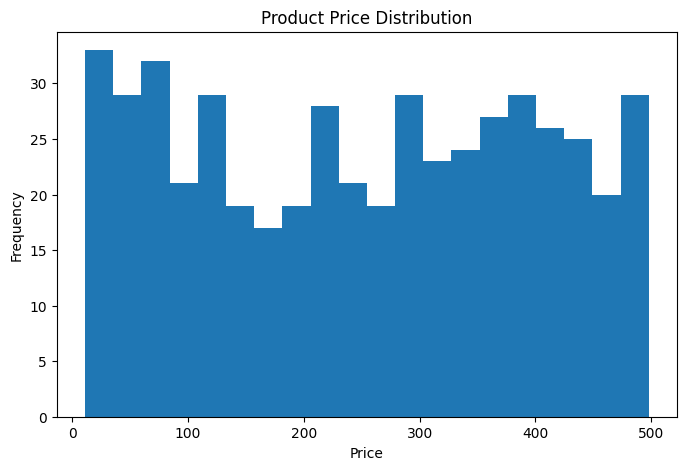

In [22]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(data['Product Price'], bins=20)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

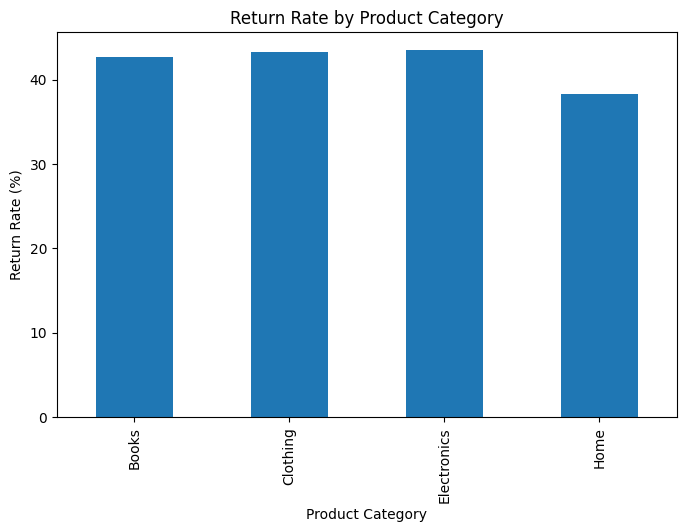


Category Return Rates:
Product Category
Electronics    43.478261
Clothing       43.333333
Books          42.666667
Home           38.317757
Name: Returns, dtype: float64


In [23]:
# Category vs Return Rate
category_return = data.groupby('Product Category')['Returns'].mean()*100

plt.figure(figsize=(8,5))
category_return.plot(kind='bar')
plt.title("Return Rate by Product Category")
plt.ylabel("Return Rate (%)")
plt.show()

print("\nCategory Return Rates:")
print(category_return.sort_values(ascending=False))

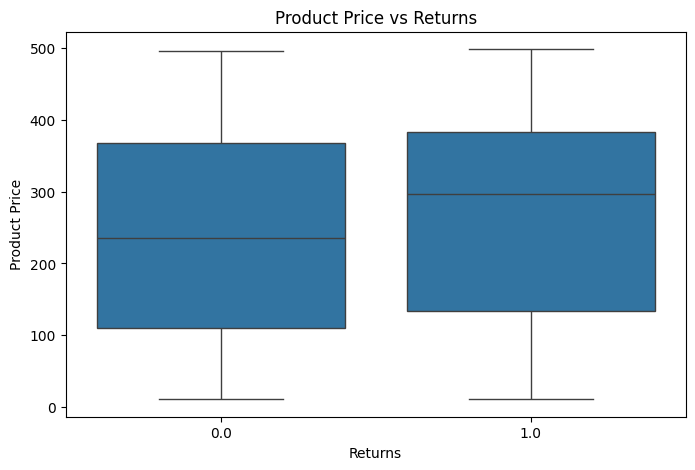

In [25]:
# Price vs Return
plt.figure(figsize=(8,5))
sns.boxplot(x='Returns', y='Product Price', data=data)
plt.title("Product Price vs Returns")
plt.show()

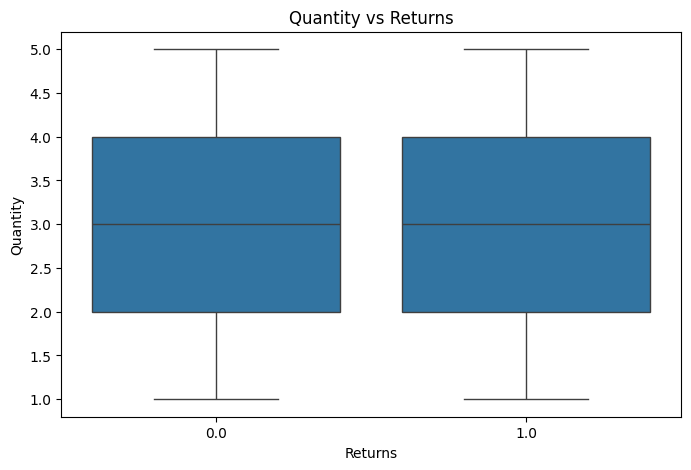

In [27]:
# Quantity vs Return
plt.figure(figsize=(8,5))
sns.boxplot(x='Returns', y='Quantity', data=data)
plt.title("Quantity vs Returns")
plt.show()

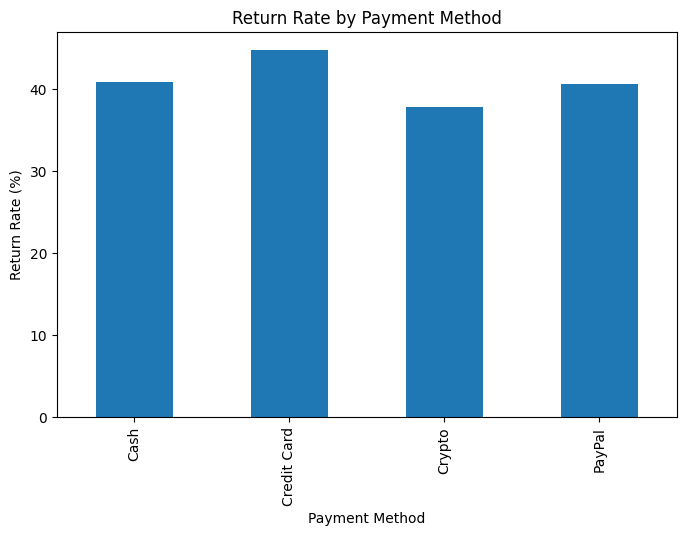

In [29]:
# Payment Method vs Return
payment_return = data.groupby('Payment Method')['Returns'].mean()*100
plt.figure(figsize=(8,5))
payment_return.plot(kind='bar')
plt.title("Return Rate by Payment Method")
plt.ylabel("Return Rate (%)")
plt.show()


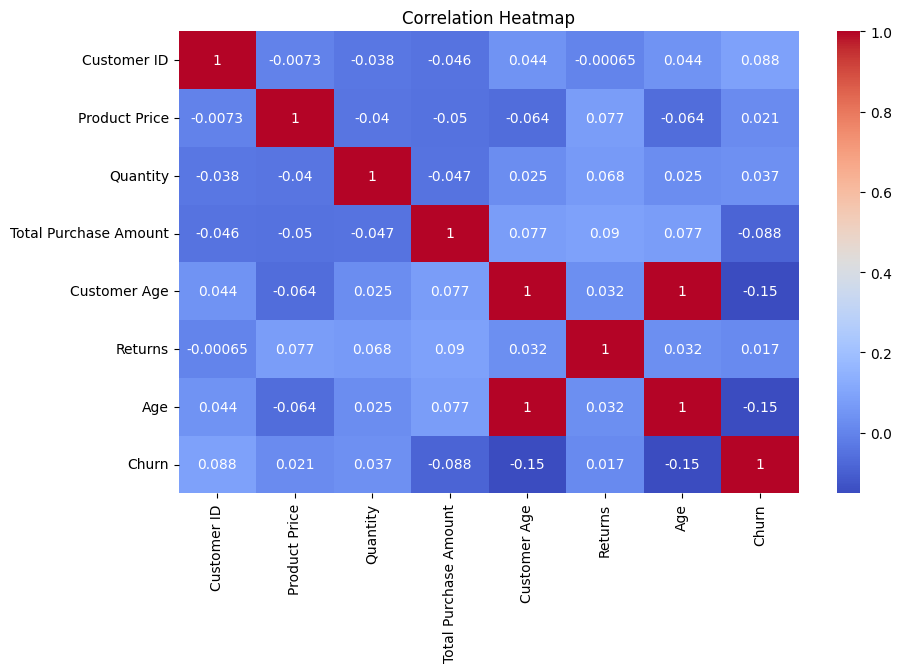

In [31]:
# Correlation Heatmap
numeric_df = data.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Number of Price Outliers: 0


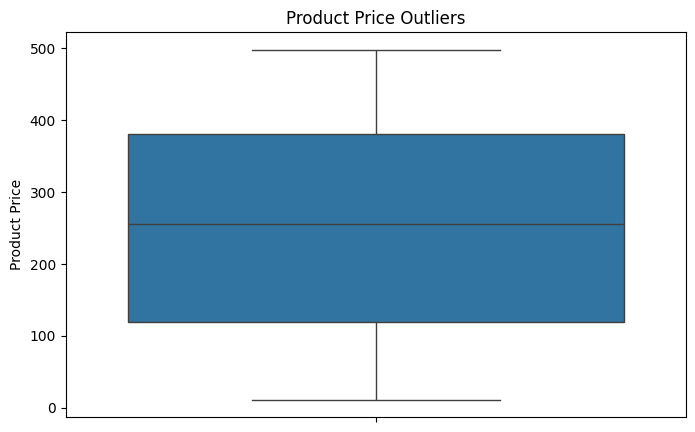

In [32]:
Q1 = data['Product Price'].quantile(0.25)
Q3 = data['Product Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data['Product Price'] < lower) |
              (data['Product Price'] > upper)]
print("\nNumber of Price Outliers:", len(outliers))
plt.figure(figsize=(8,5))
sns.boxplot(y=data['Product Price'])
plt.title("Product Price Outliers")
plt.show()

In [33]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    data['Product Category'],
    data['Returns']
)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nChi-Square Test")
print("Chi2 Statistic:", chi2)
print("P-value:", p)
if p < 0.05:
    print("Reject H0")
    print("Product Category significantly affects Returns")
else:
    print("Fail to Reject H0")
    print("No significant relationship found")


Chi-Square Test
Chi2 Statistic: 0.8130362598593303
P-value: 0.8463464583146232
Fail to Reject H0
No significant relationship found


In [35]:
# Customer Segmentation
customer_returns = data.groupby('Customer ID')['Returns'].sum()
high_return_customers = customer_returns[
    customer_returns >= 2
]
print("\nHigh Return Customers:")
print(high_return_customers.head())
premium_customers = data[
    data['Total Purchase Amount'] >
    data['Total Purchase Amount'].quantile(0.75)
]
print("\nPremium Customers Count:",
      premium_customers['Customer ID'].nunique())


High Return Customers:
Customer ID
1350    3.0
2919    3.0
3443    6.0
3576    5.0
3843    4.0
Name: Returns, dtype: float64

Premium Customers Count: 61


In [49]:
#  Business Insights
highest_category = category_return.idxmax()
print(f"Highest Return Category: {highest_category}")
print("Product category appears to be a major factor influencing returns.")
print("High-return customers should be monitored.")
print("Premium customers require special retention strategies.")
print("Focus on categories with the highest return rates to reduce losses.")

Highest Return Category: Electronics
Product category appears to be a major factor influencing returns.
High-return customers should be monitored.
Premium customers require special retention strategies.
Focus on categories with the highest return rates to reduce losses.


In [38]:
# Operations Team Recommendations
print("\n OPERATIONS RECOMMENDATIONS ")
# Highest return category
category_return = data.groupby('Product Category')['Returns'].mean() * 100
highest_category = category_return.idxmax()
# High return customers
high_return_customers = data.groupby('Customer ID')['Returns'].sum()
high_return_count = len(high_return_customers[high_return_customers >= 2])
print(f"1. Focus on reducing returns in the '{highest_category}' category.")
print("2. Strengthen product quality checks before shipping.")
print("3. Improve product descriptions and images to set accurate expectations.")
print(f"4. Monitor {high_return_count} customers with frequent returns.")
print("5. Review inventory planning for products with high return rates.")
print("6. Analyze return patterns regularly and take corrective actions.")
print("7. Provide better customer support to reduce avoidable returns.")


 OPERATIONS RECOMMENDATIONS 
1. Focus on reducing returns in the 'Electronics' category.
2. Strengthen product quality checks before shipping.
3. Improve product descriptions and images to set accurate expectations.
4. Monitor 56 customers with frequent returns.
5. Review inventory planning for products with high return rates.
6. Analyze return patterns regularly and take corrective actions.
7. Provide better customer support to reduce avoidable returns.


In [48]:
# Create Age Groups
data['Age Group'] = pd.cut(
    data['Customer Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)

# Calculate Return Rate by Age Group
age_group_returns = data.groupby('Age Group')['Returns'].mean() * 100
print("\nReturn Rate by Age Group:")
print(age_group_returns)

# Find Highest Return Age Group
highest_age_group = age_group_returns.idxmax()
highest_return_rate = age_group_returns.max()
print(f"Age Group with Highest Returns: {highest_age_group}")
print(f"Return Rate: {highest_return_rate:.2f}%")


Return Rate by Age Group:
Age Group
18-25    41.250000
26-35    39.423077
36-45    38.888889
46-55    49.038462
55+      41.322314
Name: Returns, dtype: float64
Age Group with Highest Returns: 46-55
Return Rate: 49.04%


/tmp/ipykernel_965/4050659687.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_returns = data.groupby('Age Group')['Returns'].mean() * 100


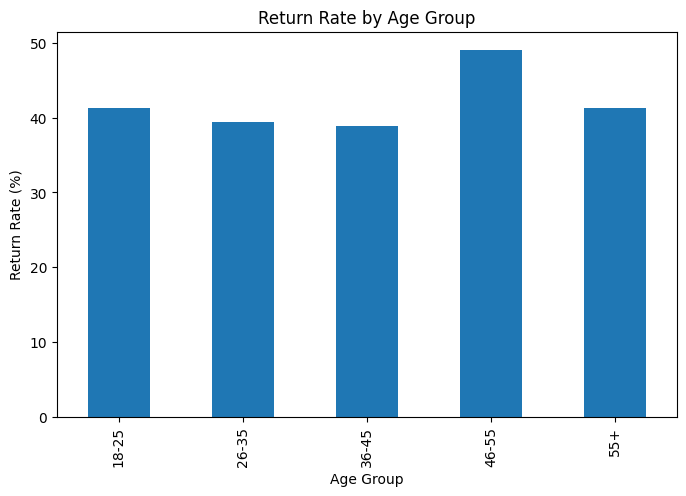

In [40]:
plt.figure(figsize=(8,5))
age_group_returns.plot(kind='bar')
plt.title('Return Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Return Rate (%)')
plt.show()

In [41]:
# Return Rate by Payment Method
payment_return = data.groupby('Payment Method')['Returns'].mean() * 100
print("\nReturn Rate by Payment Method:")
print(payment_return)
# Highest Return Payment Method
highest_payment_method = payment_return.idxmax()
highest_return_rate = payment_return.max()
print(f"Payment Method with Highest Return Rate: {highest_payment_method}")
print(f"Return Rate: {highest_return_rate:.2f}%")


Return Rate by Payment Method:
Payment Method
Cash           40.816327
Credit Card    44.776119
Crypto         37.777778
PayPal         40.645161
Name: Returns, dtype: float64
Payment Method with Highest Return Rate: Credit Card
Return Rate: 44.78%


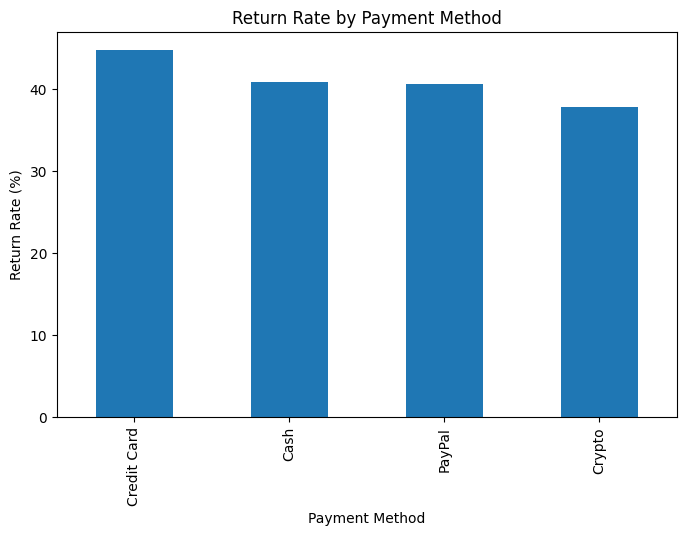

In [46]:
plt.figure(figsize=(8,5))
payment_return.sort_values(ascending=False).plot(kind='bar')
plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.show()